#📌 Extracción

In [1]:
import pandas as pd
import requests
import json

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data_json = json.loads(response.text)
df = pd.DataFrame(data_json)

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

## Conoce el Conjunto de Datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [5]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


## Comprobación de incoherencias en los datos

In [6]:
df = pd.json_normalize(data_json)

In [7]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [8]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
for col in df.select_dtypes(include='object'):
    print("Columna:", col)
    print(df[col].unique())
    print("------")

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------
Columna: Churn
['No' 'Yes' '']
------
Columna: customer.gender
['Female' 'Male']
------
Columna: customer.Partner
['Yes' 'No']
------
Columna: customer.Dependents
['Yes' 'No']
------
Columna: phone.PhoneService
['Yes' 'No']
------
Columna: phone.MultipleLines
['No' 'Yes' 'No phone service']
------
Columna: internet.InternetService
['DSL' 'Fiber optic' 'No']
------
Columna: internet.OnlineSecurity
['No' 'Yes' 'No internet service']
------
Columna: internet.OnlineBackup
['Yes' 'No' 'No internet service']
------
Columna: internet.DeviceProtection
['No' 'Yes' 'No internet service']
------
Columna: internet.TechSupport
['Yes' 'No' 'No internet service']
------
Columna: internet.StreamingTV
['Yes' 'No' 'No internet service']
------
Columna: internet.StreamingMovies
['No' 'Yes' 'No internet service']
------
Columna: account.Contract
['One year' 'Month-to-month' 'Two year']
------
Co

In [11]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [12]:
df = df[df['Churn'] != '']

In [13]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
df.shape

(7043, 21)

In [15]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [16]:
df.reset_index(drop=True, inplace=True)

In [17]:
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [18]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [19]:
df['account.Charges.Total'].dtype

dtype('float64')

In [20]:
df['account.Charges.Total'].isnull().sum()

np.int64(11)

In [21]:
df[df['account.Charges.Total'].isnull()]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
945,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1731,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1906,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2025,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2176,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2250,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2855,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3052,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3118,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4054,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [22]:
df.loc[df['account.Charges.Total'].isnull(), 'account.Charges.Total'] = 0

In [23]:
df['account.Charges.Total'].isnull().sum()

np.int64(0)

In [24]:
df['account.Charges.Total'].dtype

dtype('float64')

## Columna de cuentas diarias(opcional)

In [25]:
df['account.Charges.Monthly'].dtype

dtype('float64')

In [26]:
df['Cuentas_Diarias'] = df['account.Charges.Monthly'] / 30

In [27]:
df[['account.Charges.Monthly', 'Cuentas_Diarias']].head()

,account.Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [28]:
df['Cuentas_Diarias'].describe()

,Cuentas_Diarias
count,7043.000000
mean,2.158723
std,1.003002
min,0.608333
25%,1.183333
50%,2.345000
75%,2.995000
max,3.958333


## Manejo de inconsistencias

In [29]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].str.lower().unique())
    print("-----")

customerID ['0002-orfbo' '0003-mknfe' '0004-tlhlj' ... '9992-ujoel' '9993-lhieb'
 '9995-hotoh']
-----
Churn ['no' 'yes']
-----
customer.gender ['female' 'male']
-----
customer.Partner ['yes' 'no']
-----
customer.Dependents ['yes' 'no']
-----
phone.PhoneService ['yes' 'no']
-----
phone.MultipleLines ['no' 'yes' 'no phone service']
-----
internet.InternetService ['dsl' 'fiber optic' 'no']
-----
internet.OnlineSecurity ['no' 'yes' 'no internet service']
-----
internet.OnlineBackup ['yes' 'no' 'no internet service']
-----
internet.DeviceProtection ['no' 'yes' 'no internet service']
-----
internet.TechSupport ['yes' 'no' 'no internet service']
-----
internet.StreamingTV ['yes' 'no' 'no internet service']
-----
internet.StreamingMovies ['no' 'yes' 'no internet service']
-----
account.Contract ['one year' 'month-to-month' 'two year']
-----
account.PaperlessBilling ['yes' 'no']
-----
account.PaymentMethod ['mailed check' 'electronic check' 'credit card (automatic)'
 'bank transfer (automatic)'

In [30]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.lower().str.strip()

In [31]:
for col in df.select_dtypes(include='object').columns:
    print("Columna:", col)
    print(df[col].unique())
    print("------")

Columna: customerID
['0002-orfbo' '0003-mknfe' '0004-tlhlj' ... '9992-ujoel' '9993-lhieb'
 '9995-hotoh']
------
Columna: Churn
['no' 'yes']
------
Columna: customer.gender
['female' 'male']
------
Columna: customer.Partner
['yes' 'no']
------
Columna: customer.Dependents
['yes' 'no']
------
Columna: phone.PhoneService
['yes' 'no']
------
Columna: phone.MultipleLines
['no' 'yes' 'no phone service']
------
Columna: internet.InternetService
['dsl' 'fiber optic' 'no']
------
Columna: internet.OnlineSecurity
['no' 'yes' 'no internet service']
------
Columna: internet.OnlineBackup
['yes' 'no' 'no internet service']
------
Columna: internet.DeviceProtection
['no' 'yes' 'no internet service']
------
Columna: internet.TechSupport
['yes' 'no' 'no internet service']
------
Columna: internet.StreamingTV
['yes' 'no' 'no internet service']
------
Columna: internet.StreamingMovies
['no' 'yes' 'no internet service']
------
Columna: account.Contract
['one year' 'month-to-month' 'two year']
------
Colum

## Estandarización y transformación de datos (opcional)

In [32]:
df.columns = df.columns.str.lower().str.replace('.', '_')

In [33]:
df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

In [34]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

In [35]:
df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

In [36]:
binary_cols = [
    'churn',
    'customer_partner',
    'customer_dependents',
    'phone_phoneservice',
    'account_paperlessbilling'
]

for col in binary_cols:
    df[col] = df[col].replace({'yes': 1, 'no': 0})

/tmp/ipykernel_10315/2237605279.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'yes': 1, 'no': 0})


In [37]:
df[binary_cols].head()

,churn,customer_partner,customer_dependents,phone_phoneservice,account_paperlessbilling
0,0,1,1,1,1
1,0,0,0,1,0
2,1,0,0,1,1
3,1,1,0,1,1
4,1,1,0,1,1


In [38]:
for col in binary_cols:
    print(col, df[col].unique())
    print("Nulos:", df[col].isnull().sum())
    print("------")

churn [0 1]
Nulos: 0
------
customer_partner [1 0]
Nulos: 0
------
customer_dependents [1 0]
Nulos: 0
------
phone_phoneservice [1 0]
Nulos: 0
------
account_paperlessbilling [1 0]
Nulos: 0
------


In [39]:
df['customer_seniorcitizen'].unique()

array([0, 1])

#📊 Carga y análisis

## Análisis Descriptivo

In [41]:
df.describe()

,churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Distribución de evasión

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

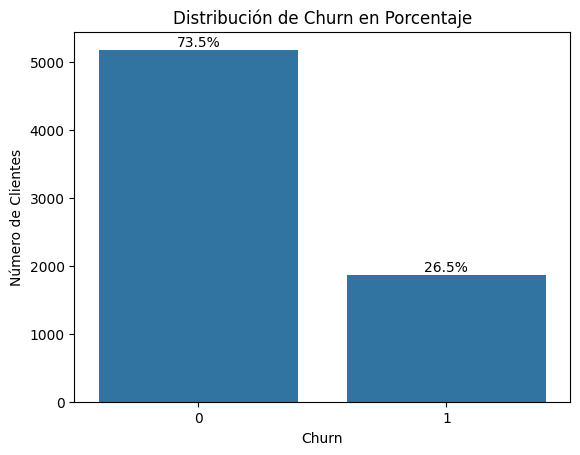

In [47]:
plt.figure()
ax = sns.countplot(x='churn', data=df)

total = len(df)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribución de Churn en Porcentaje')
plt.xlabel('Churn')
plt.ylabel('Número de Clientes')

plt.show()

## Recuento de evasión por variables categóricas

In [49]:
df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'cuentas_diarias'],
      dtype='object')

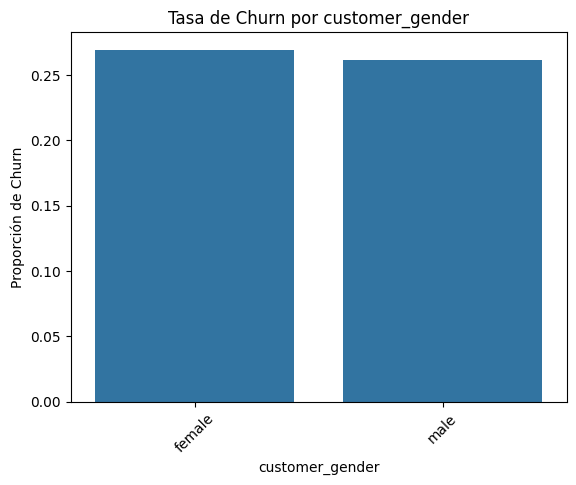

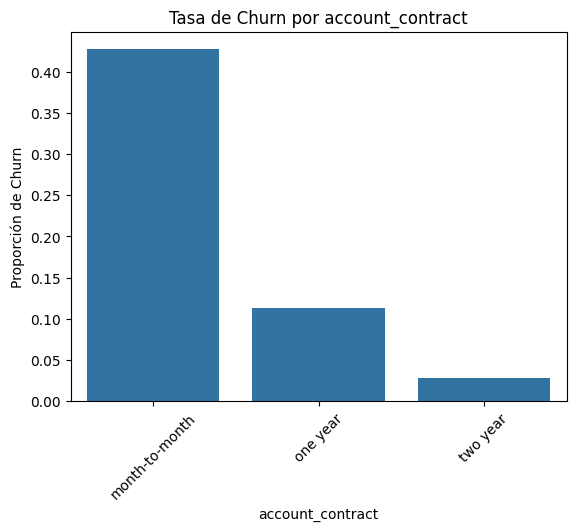

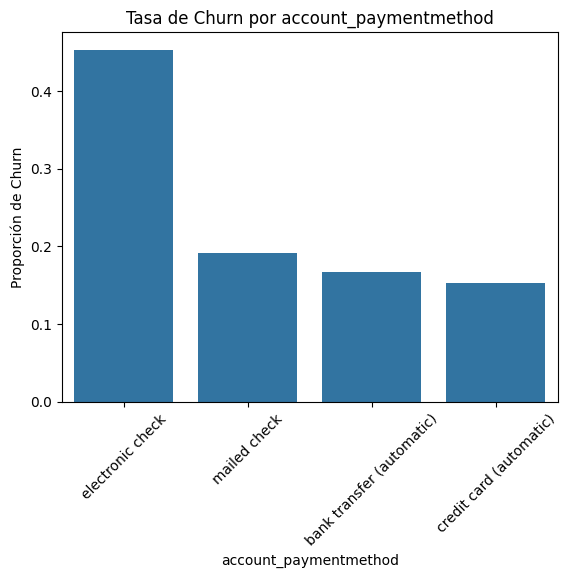

In [57]:
categorical_cols = ['customer_gender', 'account_contract', 'account_paymentmethod']

for col in categorical_cols:
    churn_rate = (
        df.groupby(col)['churn']
          .mean()
          .sort_values(ascending=False)
    )

    plt.figure()
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f'Tasa de Churn por {col}')
    plt.xlabel(col)
    plt.ylabel('Proporción de Churn')
    plt.xticks(rotation=45)
    plt.show()

## Conteo de evasión por variables numéricas

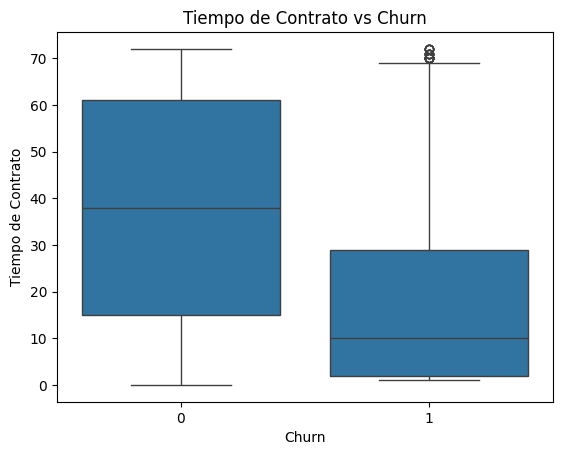

In [56]:
plt.figure()
sns.boxplot(x='churn', y='customer_tenure', data=df)
plt.title('Tiempo de Contrato vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tiempo de Contrato')
plt.show()

In [58]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if 'churn' in numeric_cols:
    numeric_cols.remove('churn')

numeric_cols

['customer_seniorcitizen',
 'customer_partner',
 'customer_dependents',
 'customer_tenure',
 'phone_phoneservice',
 'account_paperlessbilling',
 'account_charges_monthly',
 'account_charges_total',
 'cuentas_diarias']

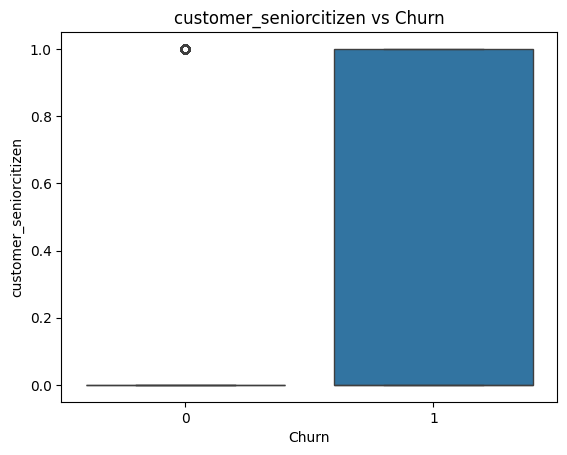

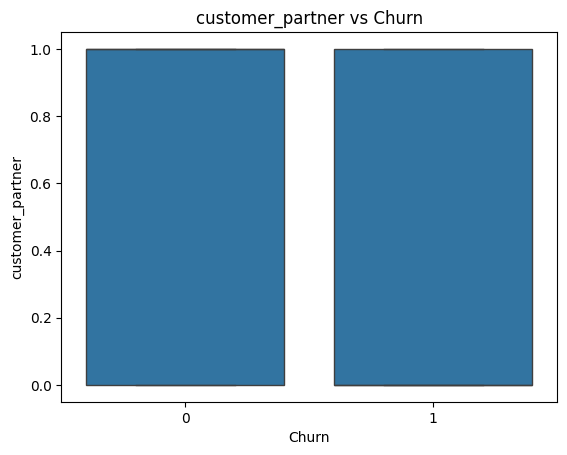

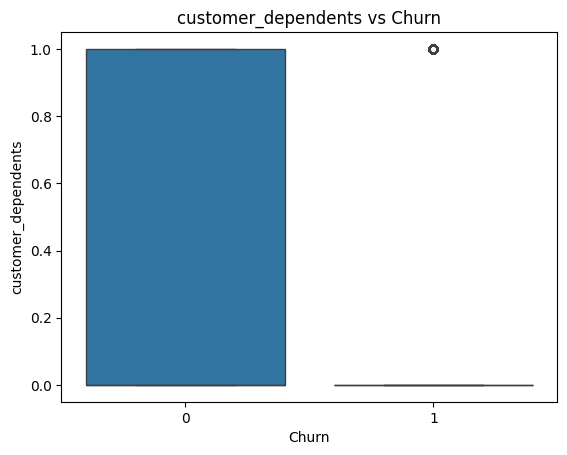

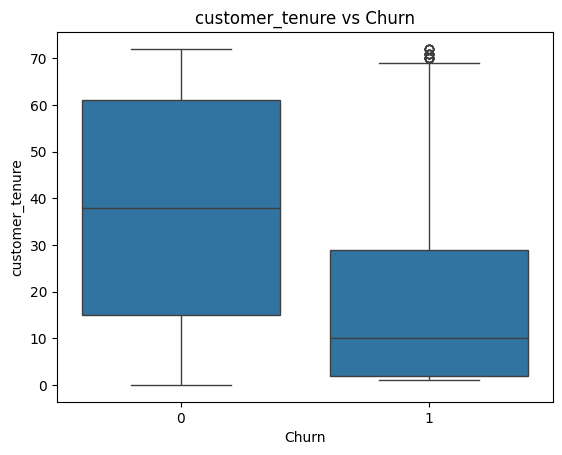

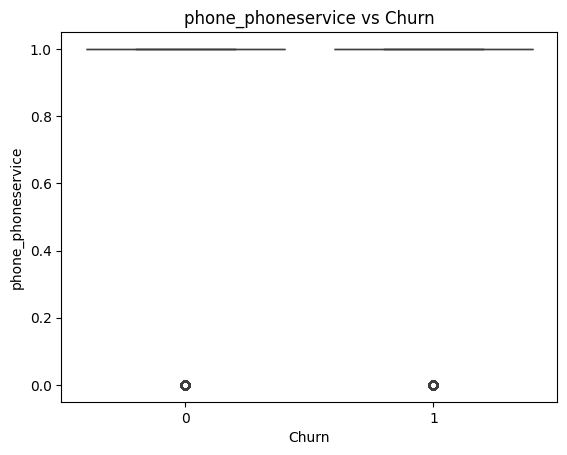

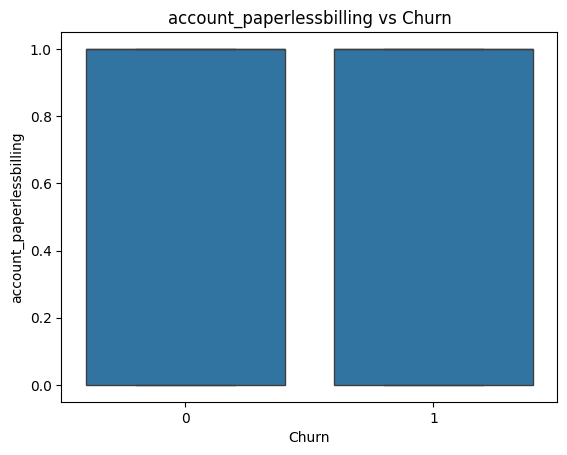

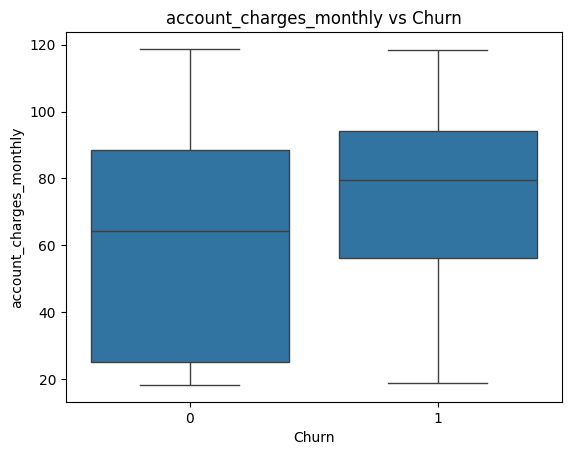

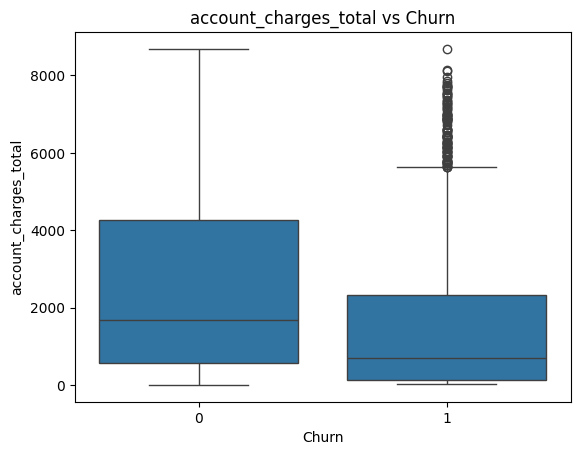

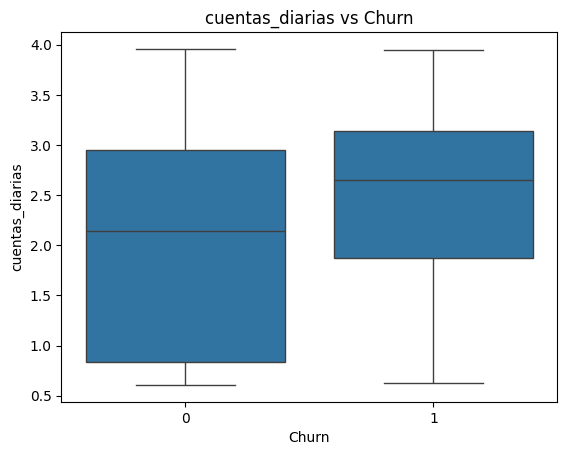

In [59]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x='churn', y=col, data=df)

    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)

    plt.show()

In [61]:
summary_stats = (
    df.groupby('churn')[numeric_cols]
      .agg(['mean', 'median', 'std'])
      .round(2)
)

summary_stats.style.background_gradient(cmap='Blues')

#📄Informe final